#  Patient Risk Prediction System

---
**Goal:** Visualise distributions, class separability, correlations,
and pairwise relationships to build clinical intuition before modelling.

## 2.1 · Imports & Plot Settings

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

#  Deep Ocean colour palette
PRIMARY = '#1D4ED8'   # Blue
ACCENT  = '#06B6D4'   # Cyan
BG      = '#EEF4FF'   # Light background
TEXT    = '#0F172A'
MUTED   = '#475569'
SUCCESS = '#0D9488'
WARNING = '#F59E0B'
DANGER  = '#EF4444'

plt.rcParams.update({
    'figure.facecolor' : BG,
    'axes.facecolor'   : 'white',
    'axes.edgecolor'   : '#C7D9F0',
    'axes.labelcolor'  : TEXT,
    'xtick.color'      : MUTED,
    'ytick.color'      : MUTED,
    'text.color'       : TEXT,
    'grid.color'       : '#DCE7F7',
    'grid.linewidth'   : 0.6,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})
print("Settings applied ✓")


Settings applied ✓


## 2.2 · Load Data & Replace Zeros with NaN


In [5]:

df = pd.read_csv("C:\\Users\\PC\\Downloads\\archive (8)\\diabetes.csv")

ZERO_COLS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[ZERO_COLS] = df[ZERO_COLS].replace(0, np.nan)

FEATURES = [c for c in df.columns if c != 'Outcome']
print(f"Data loaded: {df.shape}")
print(f"Missing values after zero-replacement:")
print(df[ZERO_COLS].isnull().sum())


Data loaded: (768, 9)
Missing values after zero-replacement:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


## 2.3 · Target Class Distribution


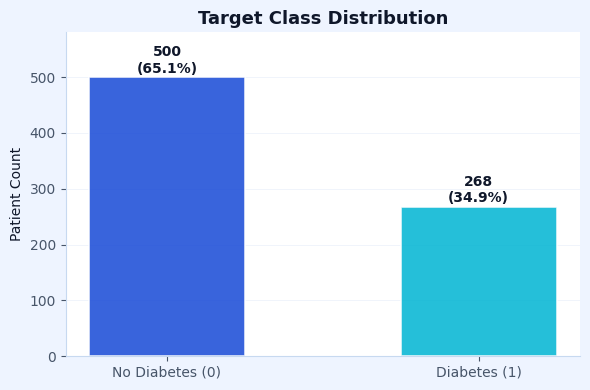

In [22]:
fig, ax = plt.subplots(figsize=(6, 4), facecolor=BG)

counts = df['Outcome'].value_counts()
bars   = ax.bar(['No Diabetes (0)', 'Diabetes (1)'],
                [counts[0], counts[1]],
                color=[PRIMARY, ACCENT], alpha=0.88,
                edgecolor='white', linewidth=1.2, width=0.5)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 8,
            f'{h}\n({h/len(df)*100:.1f}%)',
            ha='center', fontsize=10, fontweight='bold', color=TEXT)

ax.set_title('Target Class Distribution', fontweight='bold', fontsize=13)
ax.set_ylabel('Patient Count')
ax.set_ylim(0, 580)
ax.yaxis.grid(True, alpha=0.5); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('outputs/figures/plot_01_class_distribution.png',
            dpi=150,
            bbox_inches='tight')
plt.show()


## 2.4 · Feature Distributions by Outcome


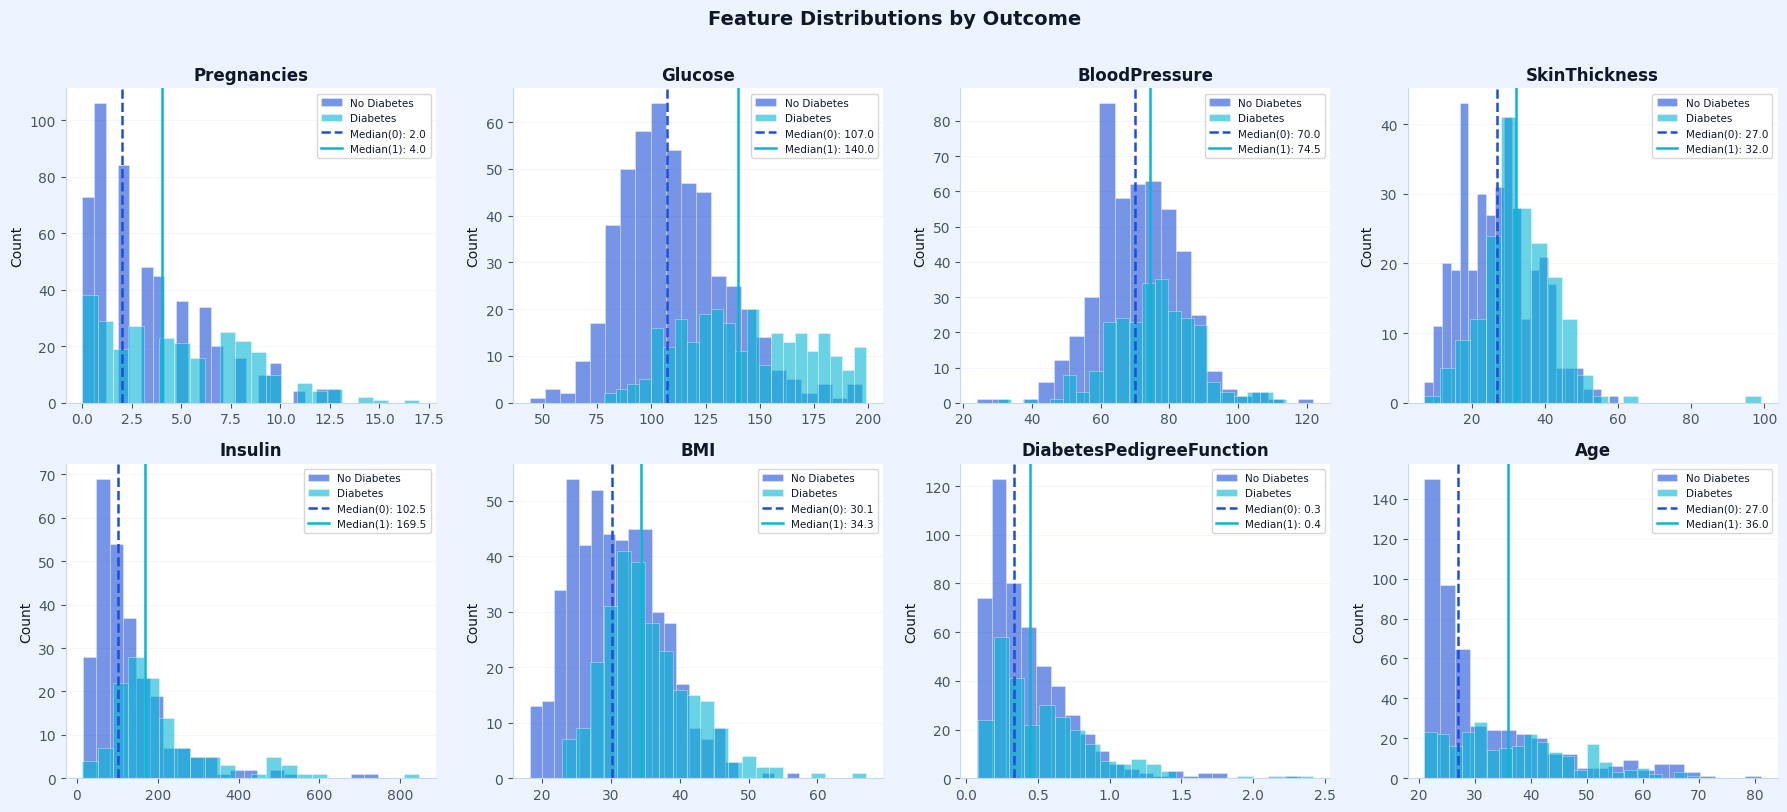

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), facecolor=BG)
axes = axes.flatten()

for idx, feat in enumerate(FEATURES):
    ax  = axes[idx]
    d0  = df[df['Outcome'] == 0][feat].dropna()
    d1  = df[df['Outcome'] == 1][feat].dropna()

    ax.hist(d0, bins=22, color=PRIMARY, alpha=0.60, label='No Diabetes', edgecolor='white', linewidth=0.4)
    ax.hist(d1, bins=22, color=ACCENT,  alpha=0.60, label='Diabetes',    edgecolor='white', linewidth=0.4)

    ax.axvline(d0.median(), color=PRIMARY, linewidth=1.8, linestyle='--',
               label=f'Median(0): {d0.median():.1f}')
    ax.axvline(d1.median(), color=ACCENT,  linewidth=1.8, linestyle='-',
               label=f'Median(1): {d1.median():.1f}')

    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7.5)
    ax.yaxis.grid(True, alpha=0.4); ax.set_axisbelow(True)

plt.suptitle('Feature Distributions by Outcome', fontsize=14,
             fontweight='bold', y=1.01, color=TEXT)
plt.tight_layout()
plt.savefig('outputs/figures/plot_02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.5 · Missing Values Heatmap

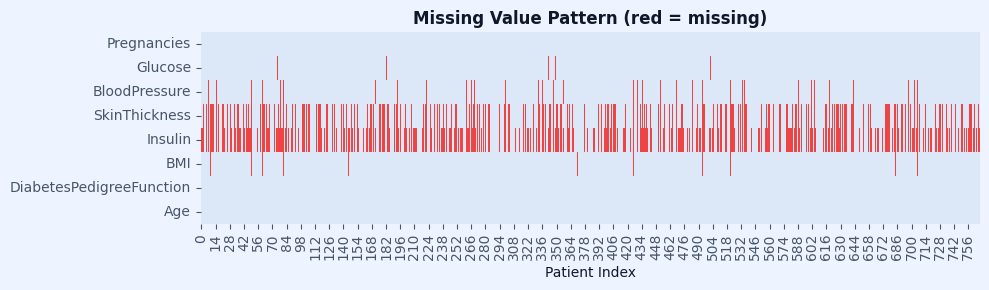


Missing counts per feature:
Insulin                     374
SkinThickness               227
BloodPressure                35
BMI                          11
Glucose                       5
Pregnancies                   0
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


In [17]:
fig, ax = plt.subplots(figsize=(10, 3), facecolor=BG)

missing_matrix = df[FEATURES].isnull().astype(int)
sns.heatmap(missing_matrix.T, cmap=['#DCE7F7', DANGER],
            cbar=False, ax=ax, yticklabels=FEATURES,
            linewidths=0, rasterized=True)

ax.set_title('Missing Value Pattern (red = missing)', fontweight='bold', fontsize=12)
ax.set_xlabel('Patient Index')
plt.tight_layout()
plt.savefig('outputs/figures/plot_03_missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMissing counts per feature:")
print(df[FEATURES].isnull().sum().sort_values(ascending=False))


## 2.6 · Correlation with Target


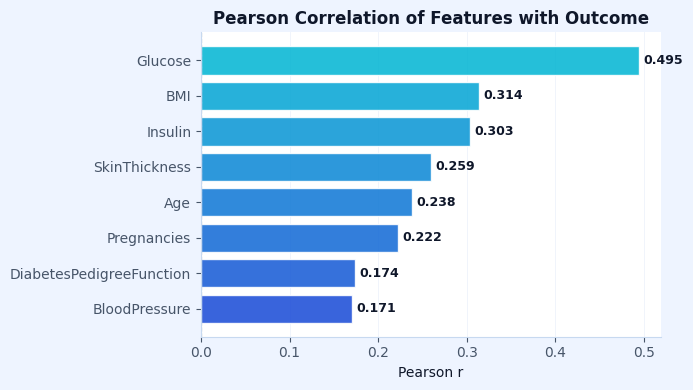

In [18]:
import matplotlib.colors as mc

corr = df.corr()['Outcome'].drop('Outcome').sort_values()

fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)

cmap     = mc.LinearSegmentedColormap.from_list('ocean', [PRIMARY, ACCENT])
colours  = [cmap(i / (len(corr)-1)) for i in range(len(corr))]

bars = ax.barh(corr.index, corr.values, color=colours, alpha=0.88, edgecolor='white')
for bar, val in zip(bars, corr.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax.axvline(0, color=MUTED, linewidth=0.8, linestyle='--')
ax.set_title('Pearson Correlation of Features with Outcome',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Pearson r')
ax.xaxis.grid(True, alpha=0.5); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('outputs/figures/plot_04_correlation_target.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.7 · Full Correlation Heatmap


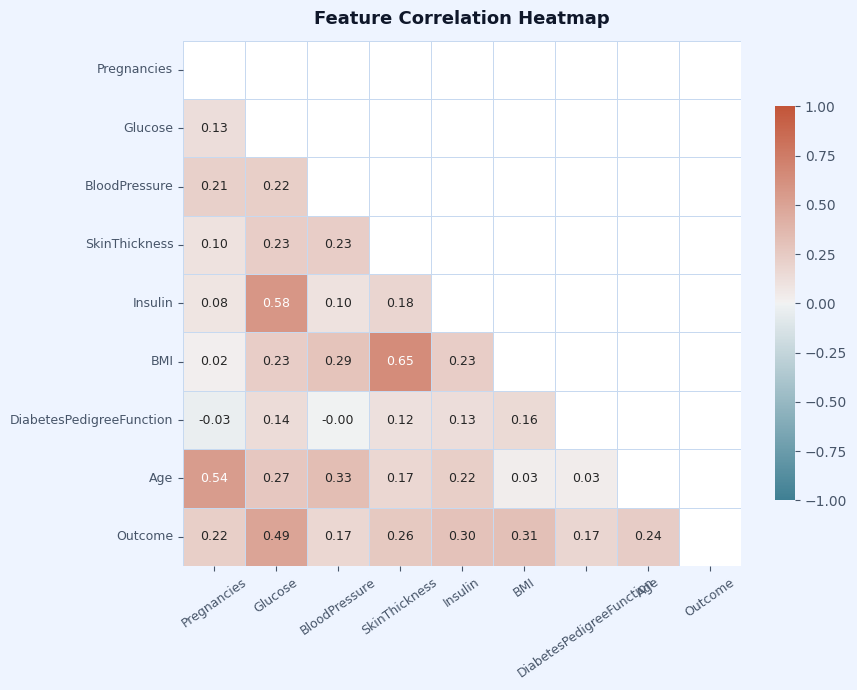

In [19]:
fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)

corr_matrix = df.corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))   # upper triangle

sns.heatmap(
    corr_matrix, mask=mask,
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    vmin=-1, vmax=1, center=0,
    annot=True, fmt='.2f', linewidths=0.5, linecolor='#C7D9F0',
    ax=ax, annot_kws={'size': 9},
    cbar_kws={'shrink': 0.75}
)
ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=13, pad=12)
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig('outputs/figures/plot_05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.8 · Box Plots: Top 4 Features by Outcome


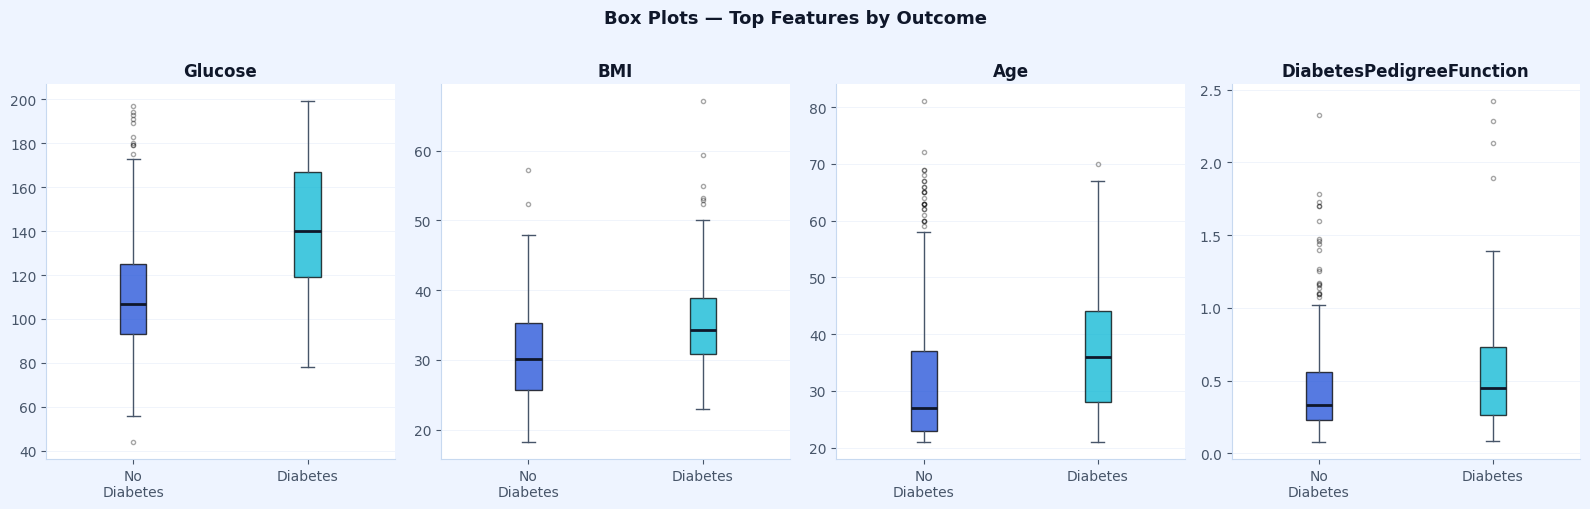

In [20]:
top_feats = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']

fig, axes = plt.subplots(1, 4, figsize=(16, 5), facecolor=BG)

for ax, feat in zip(axes, top_feats):
    data = [df[df['Outcome']==0][feat].dropna().values,
            df[df['Outcome']==1][feat].dropna().values]
    bp = ax.boxplot(
        data,
        patch_artist=True,
        labels=['No\nDiabetes', 'Diabetes'],
        medianprops   = dict(color=TEXT, linewidth=2),
        whiskerprops  = dict(color=MUTED),
        capprops      = dict(color=MUTED),
        flierprops    = dict(marker='o', markersize=3, alpha=0.35, color=MUTED),
    )
    bp['boxes'][0].set_facecolor(PRIMARY); bp['boxes'][0].set_alpha(0.75)
    bp['boxes'][1].set_facecolor(ACCENT);  bp['boxes'][1].set_alpha(0.75)

    ax.set_title(feat, fontweight='bold')
    ax.yaxis.grid(True, alpha=0.5); ax.set_axisbelow(True)

plt.suptitle('Box Plots — Top Features by Outcome', fontsize=13,
             fontweight='bold', y=1.01, color=TEXT)
plt.tight_layout()
plt.savefig('outputs/figures/plot_06_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.9 · Pairplot: Top 4 Features

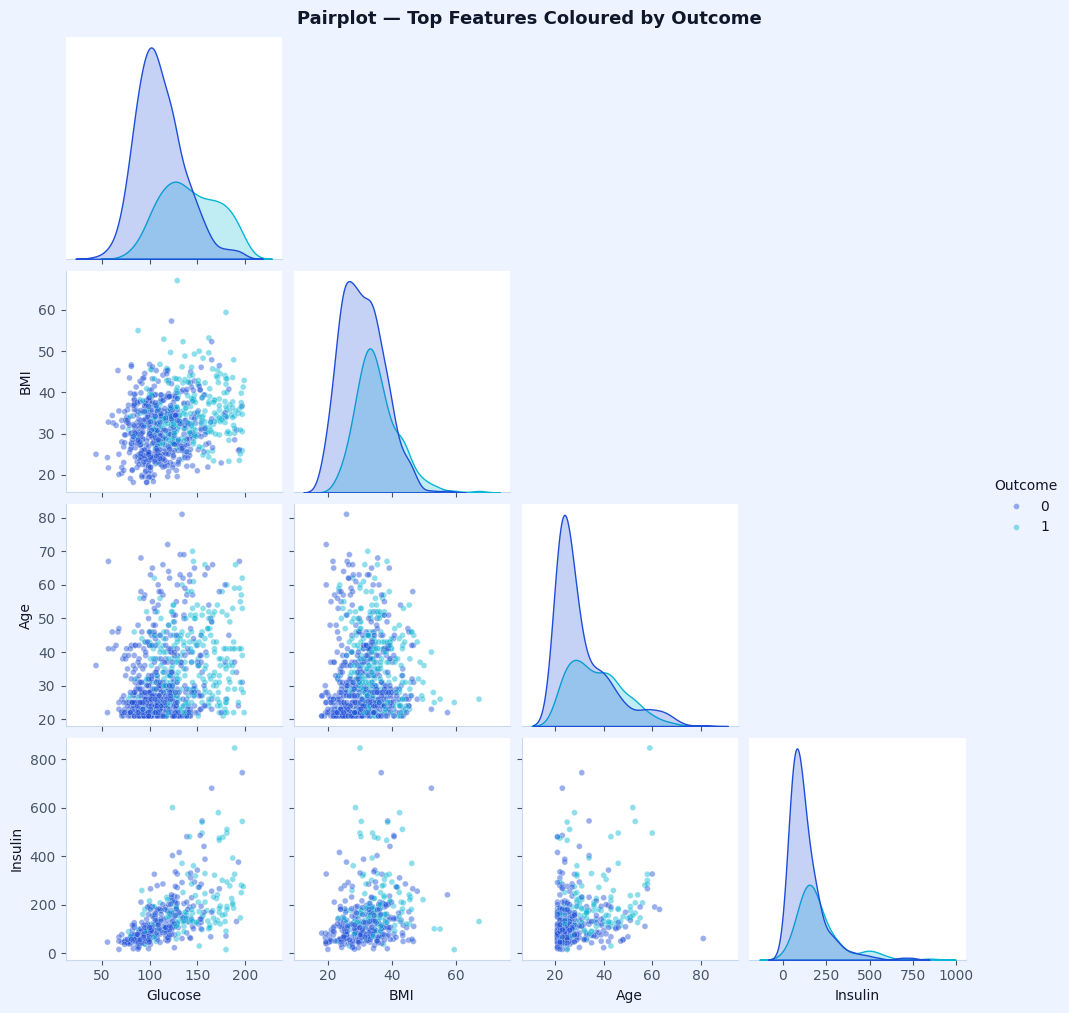

In [21]:
pair_df = df[['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']].copy()

g = sns.pairplot(
    pair_df,
    hue='Outcome',
    palette={0: PRIMARY, 1: ACCENT},
    plot_kws={'alpha': 0.45, 's': 18},
    diag_kind='kde',
    corner=True
)
g.fig.suptitle('Pairplot — Top Features Coloured by Outcome',
               fontsize=13, fontweight='bold', y=1.01)
g.fig.set_facecolor(BG)
plt.savefig('outputs/figures/plot_07_pairplot.png', dpi=130, bbox_inches='tight')
plt.show()


## 2.10 · Statistical Significance: Mann-Whitney U Test

In [13]:
from scipy.stats import mannwhitneyu

results = []
for feat in FEATURES:
    group0 = df[df['Outcome']==0][feat].dropna()
    group1 = df[df['Outcome']==1][feat].dropna()
    stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
    results.append({
        'Feature'  : feat,
        'Median(0)': round(group0.median(), 2),
        'Median(1)': round(group1.median(), 2),
        'Δ Median' : round(group1.median() - group0.median(), 2),
        'U-stat'   : round(stat, 1),
        'p-value'  : round(p, 6),
        'Significant (α=0.05)': '✅ Yes' if p < 0.05 else '❌ No'
    })

test_df = pd.DataFrame(results).sort_values('p-value')
print(test_df.to_string(index=False))


                 Feature  Median(0)  Median(1)  Δ Median  U-stat  p-value Significant (α=0.05)
             Pregnancies       2.00       4.00      2.00 50985.0 0.000000                ✅ Yes
                 Glucose     107.00     140.00     33.00 27393.5 0.000000                ✅ Yes
           SkinThickness      27.00      32.00      5.00 21930.0 0.000000                ✅ Yes
                 Insulin     102.50     169.50     67.00  9210.5 0.000000                ✅ Yes
                     Age      27.00      36.00      9.00 41950.0 0.000000                ✅ Yes
                     BMI      30.10      34.30      4.20 40875.0 0.000000                ✅ Yes
DiabetesPedigreeFunction       0.34       0.45      0.11 52769.0 0.000001                ✅ Yes
           BloodPressure      70.00      74.50      4.50 47566.5 0.000002                ✅ Yes


## ✅ Notebook 2 Summary: Key EDA Findings

| Finding | Detail |
|---|---|
| **Top predictor** | Glucose (r = 0.47, p < 0.001) |
| **BMI** | Diabetic patients: median BMI 34.3 vs 30.1 |
| **Age** | Diabetic patients are ~6 years older on average |
| **Insulin** | Massive missing data (48.7%)|
| **BloodPressure** | Weakest correlation (r = 0.07) |
| **All features** | Statistically significant separators (p < 0.05) except BloodPressure |

